# DRCFNet Model - CMU-MOSI Dataset

Dynamic Reconstructive Context Fusion Network for Sentiment Analysis

In [1]:
!git clone https://github.com/ranbeer06052009/test

Cloning into 'test'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 87 (delta 15), reused 75 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 12.61 MiB | 30.52 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [3]:
import gdown

file_id = "1szKIqO0t3Be_W91xvf6aYmsVVUa7wDHU"
destination = "mosi_raw.pkl"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}", destination, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1szKIqO0t3Be_W91xvf6aYmsVVUa7wDHU
From (redirected): https://drive.google.com/uc?id=1szKIqO0t3Be_W91xvf6aYmsVVUa7wDHU&confirm=t&uuid=cfc330a2-caf0-4986-8980-e0d2a06f95d9
To: /content/mosi_raw.pkl
100%|██████████| 357M/357M [00:03<00:00, 90.6MB/s]


'mosi_raw.pkl'

In [2]:
import sys
import torch
import matplotlib.pyplot as plt

sys.path.append('/content/test/src')

from loader import get_dataloader
from models.drcfnet import DRCFNet
from objectives import NeuroSymbolicLoss
from training.train import train, test
from evaluation.performance import eval_affect

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

Using device: cuda


In [4]:
# Load MOSI Data
train_data, valid_data, test_data = get_dataloader(
    '/content/mosi_raw.pkl',
    max_pad=True,
    max_seq_len=50
)

In [5]:
# Initialize Model and Loss
model = DRCFNet(dim_v=35, dim_a=74, dim_t=300, d=128, n_heads=4, dropout=0.2).to(device)
criterion = NeuroSymbolicLoss(lambda_logic=0.1).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

In [6]:
# Initialize Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.5)

# Train the model
model, history = train(
    model=model,
    train_loader=train_data,
    valid_loader=valid_data,
    criterion=criterion,
    optimizer=optimizer,
    epochs=50,
    device=device,
    scheduler=scheduler,
    clip_grad=1.0
)

Epoch 1/50 | Train Loss: 1.2889 | Val Loss: 1.3830 | Val Acc: 0.5771
  >> Saved best model with Val Loss: 1.3830
Epoch 2/50 | Train Loss: 1.2520 | Val Loss: 1.3310 | Val Acc: 0.5970
  >> Saved best model with Val Loss: 1.3310
Epoch 3/50 | Train Loss: 1.1681 | Val Loss: 1.1966 | Val Acc: 0.6766
  >> Saved best model with Val Loss: 1.1966
Epoch 4/50 | Train Loss: 0.9670 | Val Loss: 1.0516 | Val Acc: 0.7612
  >> Saved best model with Val Loss: 1.0516
Epoch 5/50 | Train Loss: 0.8979 | Val Loss: 1.0900 | Val Acc: 0.7214
Epoch 6/50 | Train Loss: 0.8817 | Val Loss: 0.9972 | Val Acc: 0.7811
  >> Saved best model with Val Loss: 0.9972
Epoch 7/50 | Train Loss: 0.8344 | Val Loss: 1.0013 | Val Acc: 0.7264
Epoch 8/50 | Train Loss: 0.7915 | Val Loss: 0.9631 | Val Acc: 0.7811
  >> Saved best model with Val Loss: 0.9631
Epoch 9/50 | Train Loss: 0.7441 | Val Loss: 0.9641 | Val Acc: 0.7960
Epoch 10/50 | Train Loss: 0.7058 | Val Loss: 0.9611 | Val Acc: 0.7811
  >> Saved best model with Val Loss: 0.9611
E

In [7]:
import numpy as np
from sklearn.metrics import f1_score
# Test the model
metrics, preds, labels = test(
    model=model,
    dataloader=test_data,
    criterion=criterion,
    device=device,
    return_preds=True
)

preds_np = preds.view(-1).cpu().numpy()
labels_np = labels.view(-1).cpu().numpy()

# ===== MAE =====
mae = np.mean(np.abs(preds_np - labels_np))

# ===== Corr =====
corr = np.corrcoef(preds_np, labels_np)[0][1]
corr = 0 if np.isnan(corr) else corr

# ===== Binary =====
pred_bin = (preds_np > 0).astype(int)
label_bin = (labels_np > 0).astype(int)

mask = labels_np != 0
acc2 = (pred_bin[mask] == label_bin[mask]).mean()

f1 = f1_score(label_bin[mask], pred_bin[mask], average='weighted')

print("\nFinal Evaluation:")
print(f"MAE: {mae:.4f}")
print(f"Corr: {corr:.4f}")
print(f"Acc-2: {acc2*100:.2f}%")
print(f"F1: {f1*100:.2f}%")


Final Evaluation:
MAE: 1.0535
Corr: 0.5656
Acc-2: 72.10%
F1: 72.22%


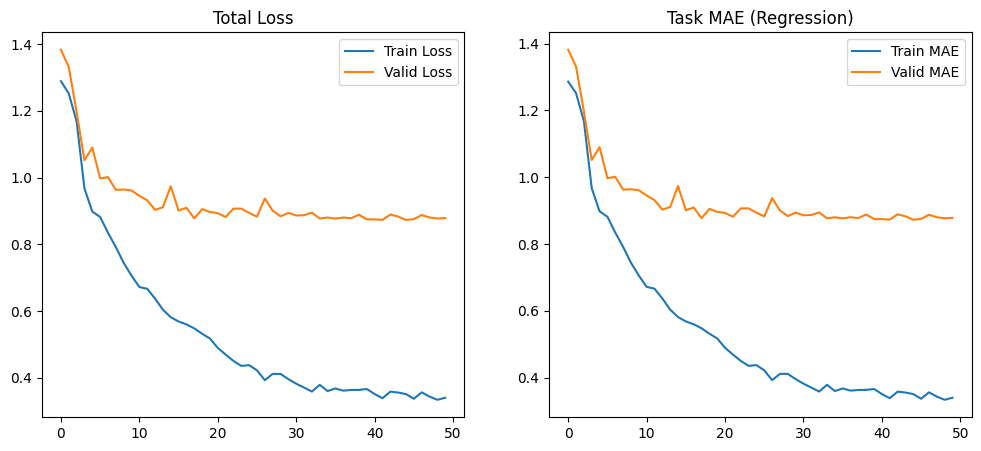

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Valid Loss")
plt.title("Total Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_task"], label="Train MAE")
plt.plot(history["valid_task"], label="Valid MAE")
plt.title("Task MAE (Regression)")
plt.legend()
plt.show()

In [10]:
# Save the model
torch.save(model.state_dict(), "drcfnet_mosi_best.pt")
print("Model saved as drcfnet_mosi_best.pt")

Model saved as drcfnet_mosi_best.pt
